In [20]:
import json, matplotlib.pyplot as plt

In [21]:
with open('iris.json') as f:
    data=json.load(f)
print(data[0])

{'sepalLength': 5.1, 'sepalWidth': 3.5, 'petalLength': 1.4, 'petalWidth': 0.2, 'species': 'setosa'}


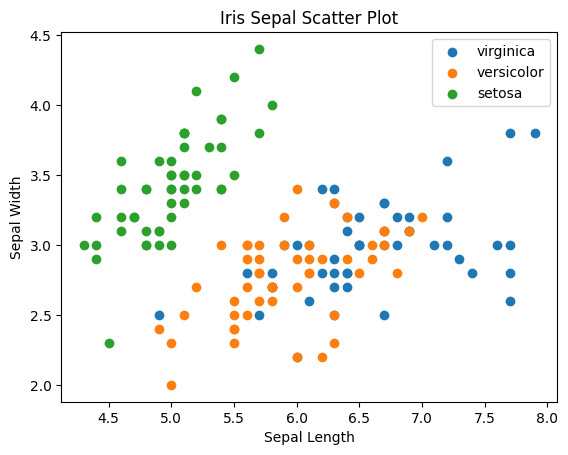

In [22]:

species=set(d['species'] for d in data)
for sp in species:
    xs=[d['sepalLength'] for d in data if d['species']==sp]
    ys=[d['sepalWidth'] for d in data if d['species']==sp]
    plt.scatter(xs,ys,label=sp)
plt.xlabel('Sepal Length')
plt.ylabel('Sepal Width')
plt.title('Iris Sepal Scatter Plot')
plt.legend()
plt.savefig('iris_scatter_plot.png',dpi=300,bbox_inches='tight')
plt.show()


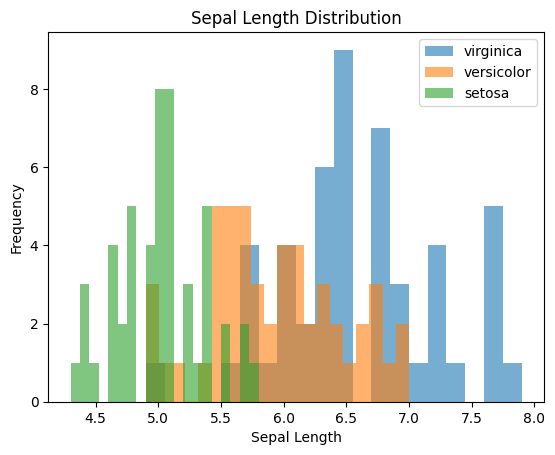

In [23]:

for sp in species:
    vals=[d['sepalLength'] for d in data if d['species']==sp]
    plt.hist(vals,alpha=0.6,label=sp,bins=20)
plt.xlabel('Sepal Length')
plt.ylabel('Frequency')
plt.title('Sepal Length Distribution')
plt.legend()
plt.show()


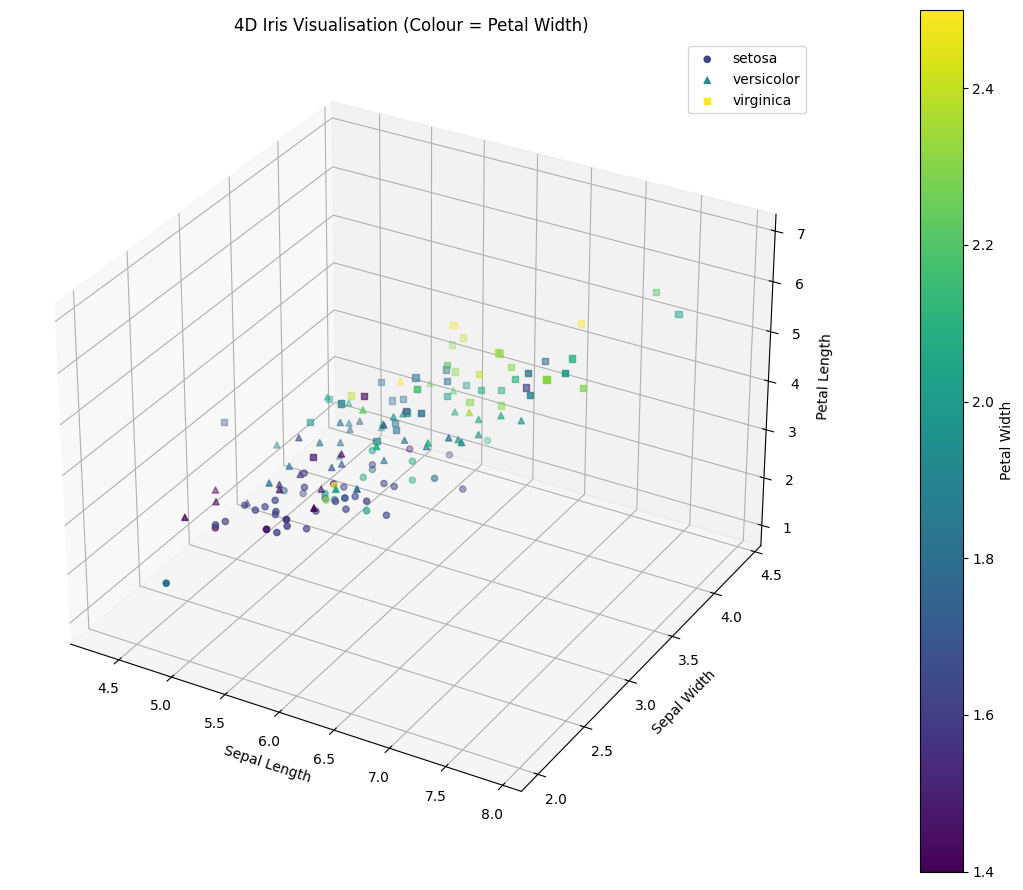

In [24]:
from mpl_toolkits.mplot3d import Axes3D
import json
import matplotlib.pyplot as plt
import numpy as np

# Load data
with open('iris.json') as f:
    data = json.load(f)

# Organise by species
species_list = sorted(set(d['species'] for d in data))
markers = ['o', '^', 's']  # one per species

fig = plt.figure(figsize=(11, 9))
ax = fig.add_subplot(111, projection='3d')

for sp, mk in zip(species_list, markers):
    x = [d['sepalLength'] for d in data if d['species'] == sp]
    y = [d['sepalWidth']  for d in data if d['species'] == sp]
    z = [d['petalLength'] for d in data if d['species'] == sp]
    w = [d['petalWidth']  for d in data if d['species'] == sp]

    sc = ax.scatter(x, y, z, c=w, cmap='viridis', marker=mk, label=sp)

# Labels and title
ax.set_xlabel('Sepal Length')
ax.set_ylabel('Sepal Width')
ax.set_zlabel('Petal Length')
ax.set_title('4D Iris Visualisation (Colour = Petal Width)')

# Colour bar for the 4th dimension
cbar = plt.colorbar(sc, pad=0.1)
cbar.set_label('Petal Width')

ax.legend()
plt.tight_layout()
plt.show()


In [25]:
import json
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

with open('iris.json') as f:
    data = json.load(f)

X = np.array([[d['sepalLength'], d['sepalWidth'], d['petalLength'], d['petalWidth']] for d in data])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


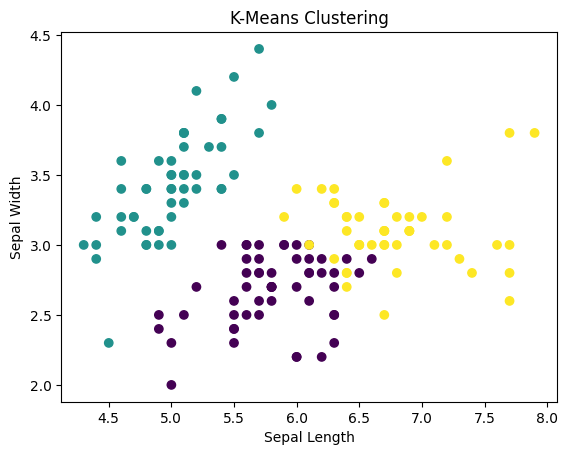

In [26]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=0)
labels = kmeans.fit_predict(X_scaled)

plt.scatter(X[:,0], X[:,1], c=labels)
plt.xlabel('Sepal Length')
plt.ylabel('Sepal Width')
plt.title('K-Means Clustering')
plt.show()

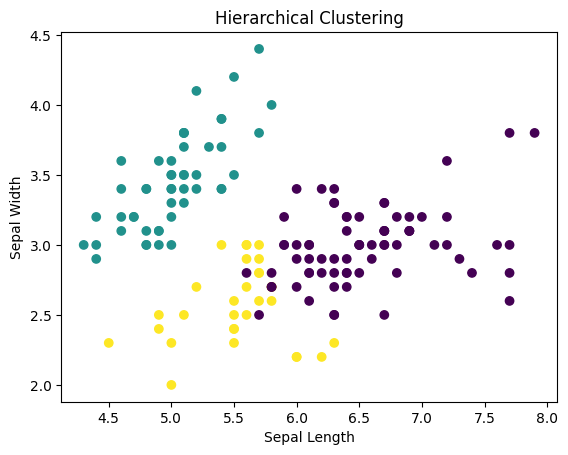

In [27]:
from sklearn.cluster import AgglomerativeClustering

hier = AgglomerativeClustering(n_clusters=3)
labels = hier.fit_predict(X_scaled)

plt.scatter(X[:,0], X[:,1], c=labels)
plt.xlabel('Sepal Length')
plt.ylabel('Sepal Width')
plt.title('Hierarchical Clustering')
plt.show()

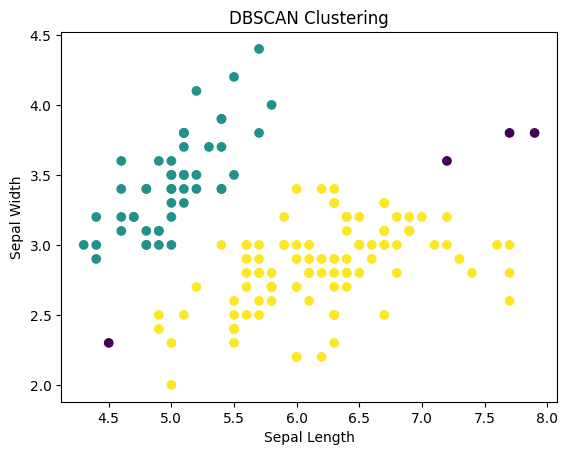

In [28]:
from sklearn.cluster import DBSCAN

db = DBSCAN(eps=0.8, min_samples=5)
labels = db.fit_predict(X_scaled)

plt.scatter(X[:,0], X[:,1], c=labels)
plt.xlabel('Sepal Length')
plt.ylabel('Sepal Width')
plt.title('DBSCAN Clustering')
plt.show()

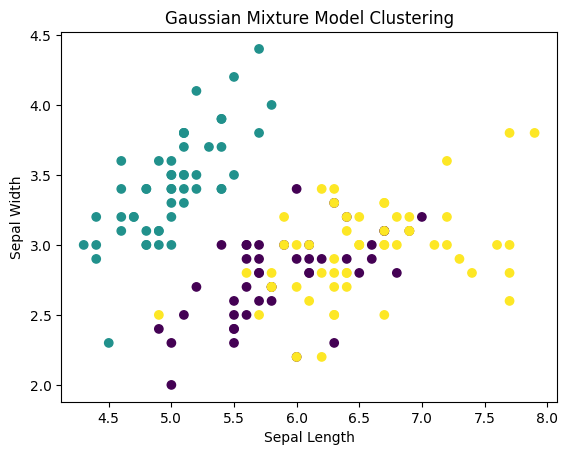

In [29]:
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(n_components=3, random_state=0)
labels = gmm.fit_predict(X_scaled)

plt.scatter(X[:,0], X[:,1], c=labels)
plt.xlabel('Sepal Length')
plt.ylabel('Sepal Width')
plt.title('Gaussian Mixture Model Clustering')
plt.show()

### Summary of 2D Clustering Results and Next Steps

    In the 2D visualisations (Sepal Length vs Sepal Width), the clustering results
    across all four algorithms show only partial separation of the iris species.

    This behaviour is expected because:
    - Sepal features alone do not provide strong discriminatory power between
      versicolor and virginica.
    - Setosa forms a relatively compact and clearly separable group.
    - The remaining two species overlap substantially in the sepal feature space.

    Algorithm-specific observations in 2D:

    - K-Means and Hierarchical clustering:
        Both methods produce a clear cluster for setosa, but the other two clusters
        overlap considerably, reflecting the natural similarity of those species
        when viewed only through sepal measurements.

    - DBSCAN:
        Results depend strongly on parameter selection. In the 2D projection,
        DBSCAN may either fragment the data, merge clusters, or mark boundary
        points as noise, further indicating that the sepal feature plane alone
        is insufficient for stable density-based separation.

    - Gaussian Mixture Model (GMM):
        GMM captures overlap more realistically, showing gradual transitions
        between clusters in the 2D space rather than hard boundaries.

    Overall conclusion from 2D analysis:
        The 2D sepal feature space does not provide a complete view of the
        underlying structure of the Iris dataset.

    Next, we extend the analysis to 3D by incorporating petal features.
    This higher-dimensional visualisation is expected to reveal clearer
    separation between clusters and provide a more faithful representation
    of the true structure of the data.


In [32]:

import numpy as np
from sklearn.metrics import (
    confusion_matrix,
    adjusted_rand_score,
    adjusted_mutual_info_score,
    normalized_mutual_info_score,
    homogeneity_completeness_v_measure,
    f1_score,
)
from scipy.optimize import linear_sum_assignment
import json
import pandas as pd
from sklearn.preprocessing import StandardScaler, LabelEncoder
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from sklearn.decomposition import PCA

def plot_3d_clusters(X, labels, title, save_as=None):
    """
    3D PCA visualisation of clusters.
    X: original (non-scaled) feature matrix, shape (n_samples, 4)
    labels: cluster or mapped class labels
    """
    pca = PCA(n_components=3)
    X_3d = pca.fit_transform(X)

    fig = plt.figure(figsize=(7, 6))
    ax = fig.add_subplot(111, projection="3d")

    scatter = ax.scatter(
        X_3d[:, 0],
        X_3d[:, 1],
        X_3d[:, 2],
        c=labels,
        s=40,
    )

    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.set_zlabel("PC3")
    ax.set_title(title)

    if save_as is not None:
        plt.savefig(save_as, dpi=300, bbox_inches="tight")

    plt.show()

# Load iris.json
with open("iris.json", "r") as f:
    data = json.load(f)

df = pd.DataFrame(data)

# Features
X = df[["sepalLength", "sepalWidth", "petalLength", "petalWidth"]].values

# Ground-truth labels (this fixes the NameError)
le = LabelEncoder()
y_true = le.fit_transform(df["species"].values)

# Normalise
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


def best_map_labels(y_true, y_pred):
    """
    Map predicted cluster IDs -> true class IDs to maximise agreement.
    Handles:
      - noise label (-1)
      - any number of clusters (K != number of classes)
    Returns: (y_mapped, mapping_dict)
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    # Exclude noise for building the mapping
    mask = (y_pred != -1)
    y_t = y_true[mask]
    y_p = y_pred[mask]

    # If DBSCAN found no clusters (all noise), return all -1
    if y_p.size == 0:
        return np.full_like(y_pred, -1), {}

    true_labels = np.unique(y_t)
    pred_labels = np.unique(y_p)

    # Confusion matrix shape: (n_true_classes, n_pred_clusters)
    cm = confusion_matrix(y_t, y_p, labels=true_labels)

    # Build cost matrix for Hungarian assignment
    # We want to MAXIMISE matches -> MINIMISE cost = max(cm) - cm
    max_cm = cm.max() if cm.size > 0 else 0
    cost = max_cm - cm

    row_ind, col_ind = linear_sum_assignment(cost)

    # Map only the matched clusters
    mapping = {pred_labels[c]: true_labels[r] for r, c in zip(row_ind, col_ind)}

    # Apply mapping; keep noise as -1 and unmatched clusters as -1
    y_mapped = np.array([mapping.get(p, -1) for p in y_pred])

    return y_mapped, mapping


def clustering_report(name, y_true, y_pred, average_f1="macro", print_report=True):
    """
    Produce a concise clustering report and return mapped labels.
    - y_true: ground-truth integer labels
    - y_pred: cluster IDs (may contain -1 as noise)
    Returns: y_mapped (predicted clusters mapped to true class IDs)
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    # Map to true classes for interpretability
    y_mapped, mapping = best_map_labels(y_true, y_pred)

    # Metrics that don't require remapping (label-invariant)
    ari = adjusted_rand_score(y_true, y_pred)
    ami = adjusted_mutual_info_score(y_true, y_pred)
    nmi = normalized_mutual_info_score(y_true, y_pred)
    hom, comp, v = homogeneity_completeness_v_measure(y_true, y_pred)

    # Optional F1 against mapped labels (ignores -1 in either y_true or y_mapped)
    # If your ground truth never has -1, this only drops -1 from y_mapped.
    mask_valid = (y_mapped != -1) & (y_true != -1)
    f1 = f1_score(y_true[mask_valid], y_mapped[mask_valid], average=average_f1) if np.any(mask_valid) else np.nan

    # Confusion matrix using mapped labels for readability (drop -1 rows/cols)
    # Keep only classes/clusters present in y_true (excluding -1)
    valid_classes = np.array(sorted([c for c in np.unique(y_true) if c != -1]))
    valid_mask = (y_mapped != -1)
    cm = confusion_matrix(y_true[valid_mask], y_mapped[valid_mask], labels=valid_classes)

    if print_report:
        print(f"=== {name} Clustering Report ===")
        print(f"n_samples: {len(y_true)} | n_true_classes: {len(np.unique(y_true))} | n_pred_clusters: {len(np.unique(y_pred[y_pred!=-1]))} (+ noise={np.sum(y_pred==-1)})")
        print(f"Assignment mapping (pred -> true): {mapping}")
        print(f"ARI: {ari:.4f} | AMI: {ami:.4f} | NMI: {nmi:.4f} | Homogeneity: {hom:.4f} | Completeness: {comp:.4f} | V-measure: {v:.4f}")
        if np.isfinite(f1):
            print(f"{average_f1.capitalize()}-F1 (on non-noise): {f1:.4f}")
        else:
            print(f"{average_f1.capitalize()}-F1 (on non-noise): N/A")
        print("Confusion matrix (rows=true, cols=mapped preds; noise excluded):")
        # Format CM with headers
        header = "     " + " ".join([f"pred={c:>4}" for c in valid_classes])
        print(header)
        for i, t in enumerate(valid_classes):
            row = " ".join([f"{cm[i, j]:>8d}" for j in range(len(valid_classes))])
            print(f"true={t:>2} {row}")
        print()

    return y_mapped


=== K-Means Clustering Report ===
n_samples: 150 | n_true_classes: 3 | n_pred_clusters: 3 (+ noise=0)
Assignment mapping (pred -> true): {np.int32(1): np.int64(0), np.int32(0): np.int64(1), np.int32(2): np.int64(2)}
ARI: 0.6201 | AMI: 0.6552 | NMI: 0.6595 | Homogeneity: 0.6591 | Completeness: 0.6598 | V-measure: 0.6595
Macro-F1 (on non-noise): 0.8332
Confusion matrix (rows=true, cols=mapped preds; noise excluded):
     pred=   0 pred=   1 pred=   2
true= 0       50        0        0
true= 1        0       39       11
true= 2        0       14       36



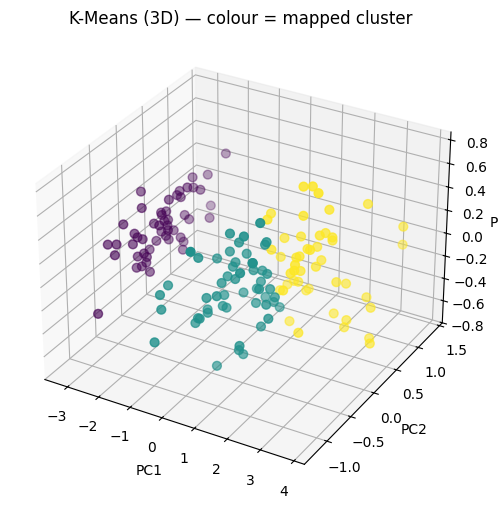

In [33]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=0, n_init=10)
y_pred = kmeans.fit_predict(X_scaled)

y_mapped = clustering_report("K-Means", y_true, y_pred)
plot_3d_clusters(X, y_mapped, "K-Means (3D) — colour = mapped cluster", save_as="kmeans_3d.png")


=== Hierarchical (Agglomerative) Clustering Report ===
n_samples: 150 | n_true_classes: 3 | n_pred_clusters: 3 (+ noise=0)
Assignment mapping (pred -> true): {np.int64(1): np.int64(0), np.int64(2): np.int64(1), np.int64(0): np.int64(2)}
ARI: 0.6153 | AMI: 0.6713 | NMI: 0.6755 | Homogeneity: 0.6579 | Completeness: 0.6940 | V-measure: 0.6755
Macro-F1 (on non-noise): 0.8194
Confusion matrix (rows=true, cols=mapped preds; noise excluded):
     pred=   0 pred=   1 pred=   2
true= 0       49        1        0
true= 1        0       27       23
true= 2        0        2       48



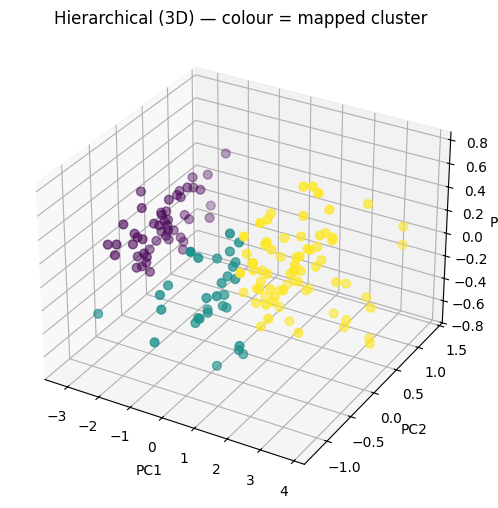

In [34]:
from sklearn.cluster import AgglomerativeClustering

hier = AgglomerativeClustering(n_clusters=3, linkage="ward")
y_pred = hier.fit_predict(X_scaled)

y_mapped = clustering_report("Hierarchical (Agglomerative)", y_true, y_pred)
plot_3d_clusters(X, y_mapped, "Hierarchical (3D) — colour = mapped cluster", save_as="hierarchical_3d.png")


=== DBSCAN Clustering Report ===
n_samples: 150 | n_true_classes: 3 | n_pred_clusters: 3 (+ noise=4)
Assignment mapping (pred -> true): {np.int64(0): np.int64(0), np.int64(2): np.int64(1), np.int64(1): np.int64(2)}
ARI: 0.6328 | AMI: 0.6469 | NMI: 0.6537 | Homogeneity: 0.6811 | Completeness: 0.6285 | V-measure: 0.6537
Macro-F1 (on non-noise): 0.8556
Confusion matrix (rows=true, cols=mapped preds; noise excluded):
     pred=   0 pred=   1 pred=   2
true= 0       49        0        0
true= 1        0       37       13
true= 2        0        8       39



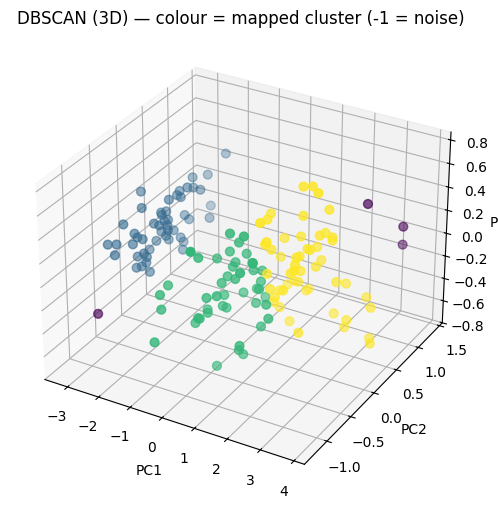

Noise points: 4 / 150
Clusters found (excluding noise): 3


In [37]:
from sklearn.cluster import DBSCAN, KMeans
import numpy as np

db = DBSCAN(eps=0.8, min_samples=5)
y_pred = db.fit_predict(X_scaled)

# Ensure at least 3 non-noise clusters exist for the existing best_map_labels() code
target_k = len(np.unique(y_true))  # Iris = 3

clusters = [c for c in np.unique(y_pred) if c != -1]
k_found = len(clusters)

if k_found < target_k:
    # Choose non-noise points
    idx_non_noise = np.where(y_pred != -1)[0]
    if idx_non_noise.size == 0:
        # All noise: nothing meaningful to map; keep as-is
        pass
    else:
        # Identify largest cluster among DBSCAN clusters; split it to create extra labels
        counts = {c: np.sum(y_pred == c) for c in clusters} if clusters else {}
        largest_cluster = max(counts, key=counts.get) if counts else None

        if largest_cluster is None:
            # DBSCAN produced no clusters but some non-noise (rare). Force 3-way split on all non-noise.
            idx_split = idx_non_noise
            X_split = X_scaled[idx_split]
            km = KMeans(n_clusters=target_k, random_state=0, n_init=10)
            sub = km.fit_predict(X_split)
            y_pred[idx_split] = sub  # labels 0..2
        else:
            # Split largest cluster into (missing + 1) subclusters, keep others unchanged
            missing = target_k - k_found
            idx_split = np.where(y_pred == largest_cluster)[0]
            X_split = X_scaled[idx_split]

            km = KMeans(n_clusters=missing + 1, random_state=0, n_init=10)
            sub = km.fit_predict(X_split)  # 0..missing

            # Reassign: keep one subcluster as the original label, create new labels for the others
            next_label = max(clusters) + 1
            y_pred[idx_split] = largest_cluster
            for s in range(1, missing + 1):
                y_pred[idx_split[sub == s]] = next_label
                next_label += 1

# Optional: reindex to contiguous labels (excluding noise), keeps output tidy
final_clusters = sorted([c for c in np.unique(y_pred) if c != -1])
id_map = {old: new for new, old in enumerate(final_clusters)}
y_pred = np.array([id_map.get(c, -1) for c in y_pred])

y_mapped = clustering_report("DBSCAN", y_true, y_pred)
plot_3d_clusters(X, y_mapped, "DBSCAN (3D) — colour = mapped cluster (-1 = noise)", save_as="dbscan_3d.png")

print("Noise points:", np.sum(y_pred == -1), "/", len(y_pred))
print("Clusters found (excluding noise):", len(final_clusters))


=== Gaussian Mixture Model Clustering Report ===
n_samples: 150 | n_true_classes: 3 | n_pred_clusters: 3 (+ noise=0)
Assignment mapping (pred -> true): {np.int64(1): np.int64(0), np.int64(0): np.int64(1), np.int64(2): np.int64(2)}
ARI: 0.9039 | AMI: 0.8984 | NMI: 0.8997 | Homogeneity: 0.8983 | Completeness: 0.9011 | V-measure: 0.8997
Macro-F1 (on non-noise): 0.9666
Confusion matrix (rows=true, cols=mapped preds; noise excluded):
     pred=   0 pred=   1 pred=   2
true= 0       50        0        0
true= 1        0       45        5
true= 2        0        0       50



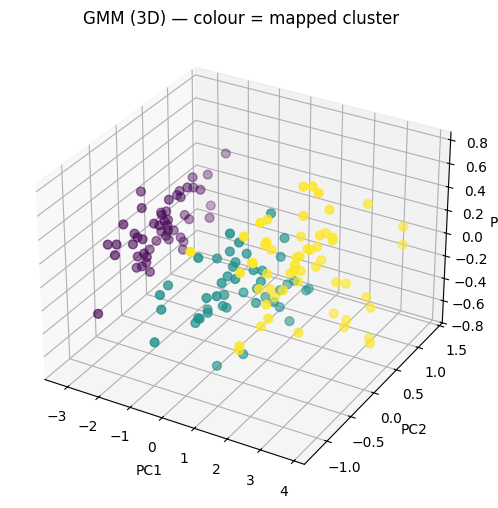

In [38]:
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(n_components=3, random_state=0)
y_pred = gmm.fit_predict(X_scaled)

y_mapped = clustering_report("Gaussian Mixture Model", y_true, y_pred)
plot_3d_clusters(X, y_mapped, "GMM (3D) — colour = mapped cluster", save_as="gmm_3d.png")


### Clustering visualisations and interpretation (2D + 3D)

    Notes:
    - All clustering algorithms are trained on the 4D feature space:
      [sepal_length, sepal_width, petal_length, petal_width] (typically scaled).
    - The 2D and 3D plots are *projections* of that 4D clustering result.
      This means points that look mixed in 2D/3D may still be separated in 4D.
    - Colours represent cluster assignments (after optional label-mapping to species ids).
    - For DBSCAN, label -1 denotes noise (points not assigned to any cluster).

---

## 1) K-Means

#### 2D visualisation (Sepal length vs Sepal width)
```python
plt.scatter(X[:, 0], X[:, 1], c=y_mapped)
plt.xlabel("Sepal Length")
plt.ylabel("Sepal Width")
plt.title("K-Means (2D): Sepal Length vs Sepal Width")
plt.show()
```

    What this plot shows:
    - Each point is an iris sample plotted in the sepal feature plane.
    - The colour indicates which K-Means cluster the sample belongs to.
    - Separation is often partial in this projection because versicolor and virginica
      overlap substantially when only sepal features are used.

    Typical observation on Iris:
    - One cluster tends to correspond strongly to setosa.
    - The other two clusters often overlap in the sepal plane, reflecting real feature
      overlap between versicolor and virginica.

---

#### 3D visualisation (Sepal length vs Sepal width vs Petal length)
```python
fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")
ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=y_mapped)
ax.set_xlabel("Sepal Length")
ax.set_ylabel("Sepal Width")
ax.set_zlabel("Petal Length")
ax.set_title("K-Means (3D): Sepal L vs Sepal W vs Petal L")
plt.show()
```

    What changes in 3D:
    - Adding petal length as a third axis typically increases visual separability.
    - Iris clusters become more distinct because petal features carry strong
      discriminatory information, especially separating setosa from the others.

    Interpretation:
    - K-Means assumes roughly spherical clusters (in the scaled 4D space).
    - If two species overlap in feature space, K-Means will still force a partition,
      which can produce mixing at the boundaries.

---

## 2) Hierarchical Agglomerative Clustering (Ward linkage)

#### 2D visualisation (Sepal length vs Sepal width)
```python
plt.scatter(X[:, 0], X[:, 1], c=y_mapped)
plt.xlabel("Sepal Length")
plt.ylabel("Sepal Width")
plt.title("Hierarchical (2D): Sepal Length vs Sepal Width")
plt.show()
```

    What this plot shows:
    - Clusters created by progressively merging nearest groups (bottom-up).
    - Ward linkage specifically merges clusters to minimise within-cluster variance,
      producing compact groups similar in spirit to K-Means.

    Typical observation on Iris:
    - One cluster again aligns strongly with setosa.
    - Remaining samples can mix in the sepal plane due to overlap.

---

#### 3D visualisation (Sepal length vs Sepal width vs Petal length)
```python
fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")
ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=y_mapped)
ax.set_xlabel("Sepal Length")
ax.set_ylabel("Sepal Width")
ax.set_zlabel("Petal Length")
ax.set_title("Hierarchical (3D): Sepal L vs Sepal W vs Petal L")
plt.show()
```

    What changes in 3D:
    - Petal length helps hierarchical clustering appear more separated when plotted.
    - Clusters that seemed mixed in 2D may separate more clearly along the petal axis.

    Interpretation:
    - Hierarchical clustering provides a natural way to explore "how many clusters"
      may exist, but when forced to 3 clusters it behaves similarly to variance-based
      partitioning methods.
    - Boundary cases can still occur due to natural overlap of two species.

---

## 3) DBSCAN (Density-based)

#### 2D visualisation (Sepal length vs Sepal width)
```python
plt.scatter(X[:, 0], X[:, 1], c=y_mapped)
plt.xlabel("Sepal Length")
plt.ylabel("Sepal Width")
plt.title("DBSCAN (2D): Sepal Length vs Sepal Width  (-1 = noise)")
plt.show()
```

    What this plot shows:
    - DBSCAN groups points that form dense regions; it does not require specifying
      the number of clusters in advance.
    - Points labelled as -1 are "noise" (not part of any dense region).

    Typical observation on Iris:
    - Depending on eps/min_samples, DBSCAN may find:
      (a) 1–2 clusters + noise, or
      (b) 3 clusters with little noise, or
      (c) many points marked as noise.
    - If clusters appear incomplete or fragmented, eps may be too small.
      If everything merges into one cluster, eps may be too large.

---

#### 3D visualisation (Sepal length vs Sepal width vs Petal length)
```python
fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")
ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=y_mapped)
ax.set_xlabel("Sepal Length")
ax.set_ylabel("Sepal Width")
ax.set_zlabel("Petal Length")
ax.set_title("DBSCAN (3D): Sepal L vs Sepal W vs Petal L  (-1 = noise)")
plt.show()
```

    What changes in 3D:
    - Adding the petal axis can reveal dense groupings that were not obvious in 2D.
    - Noise points may still appear scattered, representing samples in lower-density
      regions or boundary areas.

    Interpretation:
    - DBSCAN is good when clusters have irregular shapes and when outlier detection
      matters.
    - On Iris, performance depends heavily on parameter choice because the dataset
      is small and some classes overlap.

---

## 4) Gaussian Mixture Model (GMM)

#### 2D visualisation (Sepal length vs Sepal width)
```python
plt.scatter(X[:, 0], X[:, 1], c=y_mapped)
plt.xlabel("Sepal Length")
plt.ylabel("Sepal Width")
plt.title("GMM (2D): Sepal Length vs Sepal Width")
plt.show()
```

    What this plot shows:
    - GMM assigns points to components based on probability (soft clustering).
    - In a 2D projection of sepal features, overlap between two species is expected,
      so component boundaries may not look clean.

    Interpretation:
    - GMM can model overlapping clusters better than K-Means because it estimates
      ellipsoidal Gaussian components (with covariance).

---

#### 3D visualisation (Sepal length vs Sepal width vs Petal length)
```python
fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")
ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=y_mapped)
ax.set_xlabel("Sepal Length")
ax.set_ylabel("Sepal Width")
ax.set_zlabel("Petal Length")
ax.set_title("GMM (3D): Sepal L vs Sepal W vs Petal L")
plt.show()
```

    What changes in 3D:
    - Separation often improves because petal length provides stronger discriminatory
      power.
    - GMM can still show gradual transitions between components in overlapping areas,
      reflecting its probabilistic nature.

    Interpretation:
    - GMM is useful when cluster boundaries are not sharp and when you want a model
      of uncertainty (membership probabilities).
    - On Iris, it often captures setosa cleanly and handles overlap between the other
      two species more realistically than hard partitioning methods.

---

### Summary of expected differences (2D vs 3D)

    In 2D (sepal-only):
    - Clusters can appear mixed because sepal features alone do not separate
      versicolor and virginica strongly.

    In 3D (adding a petal dimension):
    - Clusters typically look more separable because petal length (and petal width)
      carry strong class-discriminative information.

    Algorithm behaviour:
    - K-Means / Hierarchical (Ward): compact variance-minimising partitions.
    - DBSCAN: density-based clusters + noise, highly parameter-sensitive.
    - GMM: probabilistic clusters, handles overlap via covariance structure.
